# Notebook 02 — Segmentation & Polar Normalization
Walks through iris segmentation and rubber-sheet normalization on individual images.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

Found 384 images
Image: 001L_1.png  shape=(576, 768)


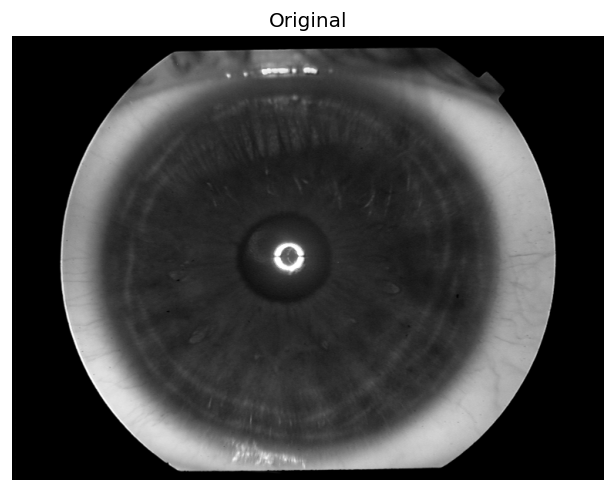

In [3]:
# ── Pick a test image ────────────────────────
DATA_ROOT = Path('./raw')
images = list(DATA_ROOT.rglob('*.jpg')) + list(DATA_ROOT.rglob('*.png'))
print(f'Found {len(images)} images')

# Use first image
img_path = images[0]
gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
print(f'Image: {img_path.name}  shape={gray.shape}')
plt.imshow(gray, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.show()

Pupil:  cx=221, cy=241, r=155
Iris:   cx=303, cy=250, r=232


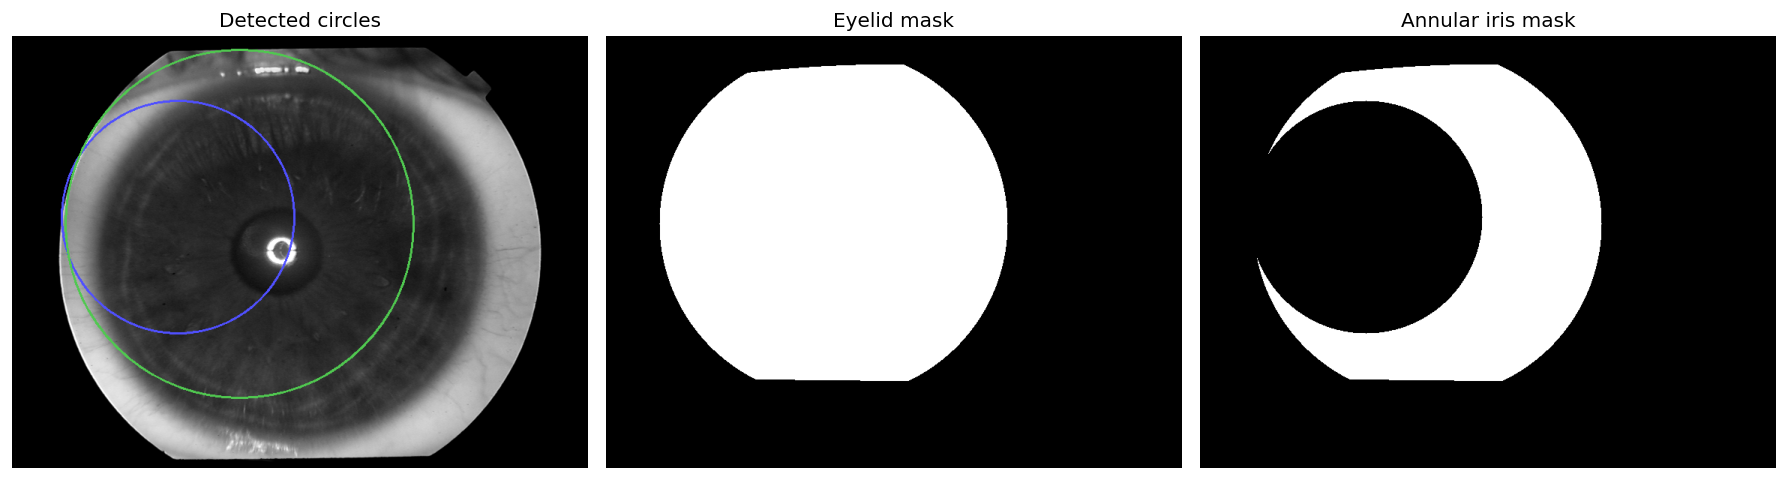

In [5]:
# ── Segmentation ─────────────────────────────
from segmentation import detect_pupil, detect_iris, build_eyelid_mask, build_annular_mask

pupil = detect_pupil(gray)
print(f'Pupil:  cx={pupil[0]}, cy={pupil[1]}, r={pupil[2]}')

iris_c = detect_iris(gray, pupil)
print(f'Iris:   cx={iris_c[0]}, cy={iris_c[1]}, r={iris_c[2]}')

eyelid_mask  = build_eyelid_mask(gray, iris_c)
annular_mask = build_annular_mask(gray.shape, pupil, iris_c, eyelid_mask)

# Visualise
vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.circle(vis, (pupil[0], pupil[1]), pupil[2], (255, 80, 80), 2)
cv2.circle(vis, (iris_c[0], iris_c[1]), iris_c[2], (80, 200, 80), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[0].set_title('Detected circles'); axes[0].axis('off')
axes[1].imshow(eyelid_mask, cmap='gray')
axes[1].set_title('Eyelid mask'); axes[1].axis('off')
axes[2].imshow(annular_mask, cmap='gray')
axes[2].set_title('Annular iris mask'); axes[2].axis('off')
plt.tight_layout(); plt.show()

Strip shape : (64, 512)
Strip range : [0.000, 1.000]
Strip std   : 0.2033


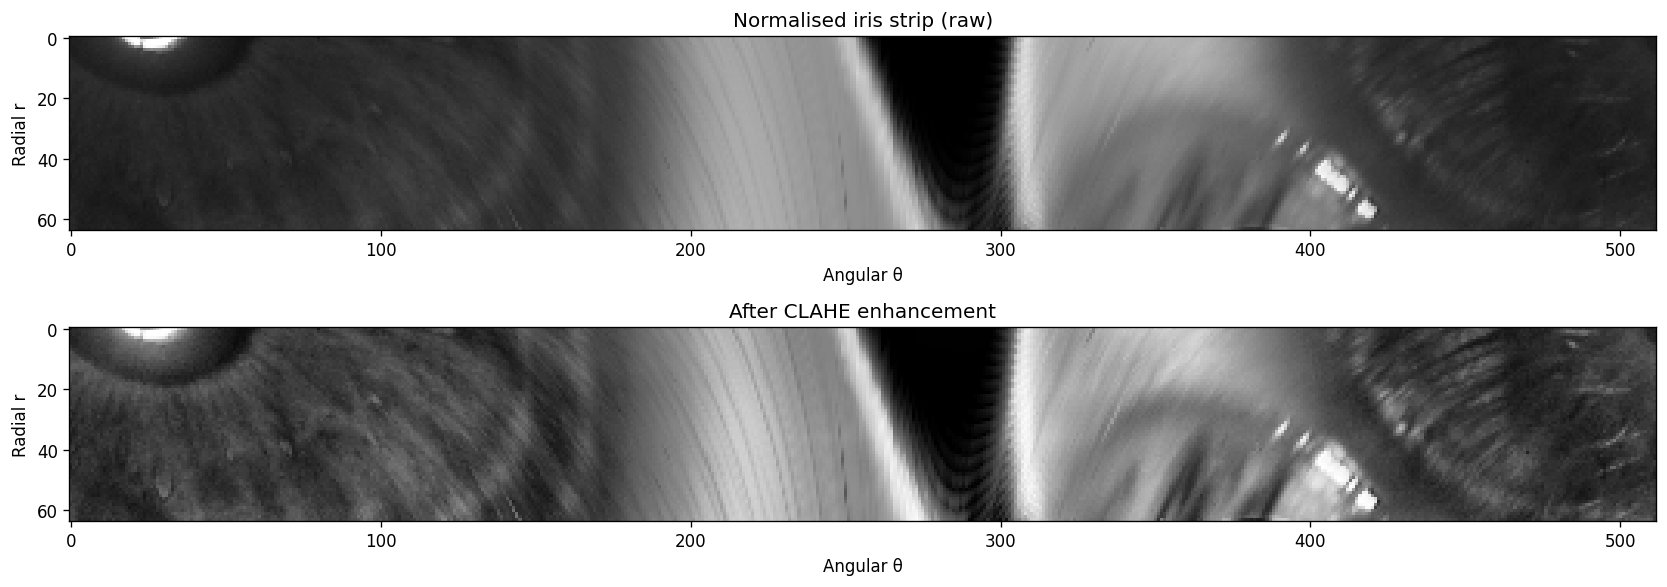

In [7]:
# ── Rubber-sheet normalization ───────────────
from normalization import rubber_sheet_normalize, apply_clahe

strip        = rubber_sheet_normalize(gray, pupil, iris_c)
strip_clahe  = apply_clahe(strip)

print(f'Strip shape : {strip.shape}')
print(f'Strip range : [{strip.min():.3f}, {strip.max():.3f}]')
print(f'Strip std   : {strip.std():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].imshow(strip,       cmap='gray', aspect='auto')
axes[0].set_title('Normalised iris strip (raw)')
axes[0].set_xlabel('Angular θ'); axes[0].set_ylabel('Radial r')
axes[1].imshow(strip_clahe, cmap='gray', aspect='auto')
axes[1].set_title('After CLAHE enhancement')
axes[1].set_xlabel('Angular θ'); axes[1].set_ylabel('Radial r')
plt.tight_layout(); plt.show()

c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\augmentation.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(2.0, 12.0), p=0.3),
c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\augmentation.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


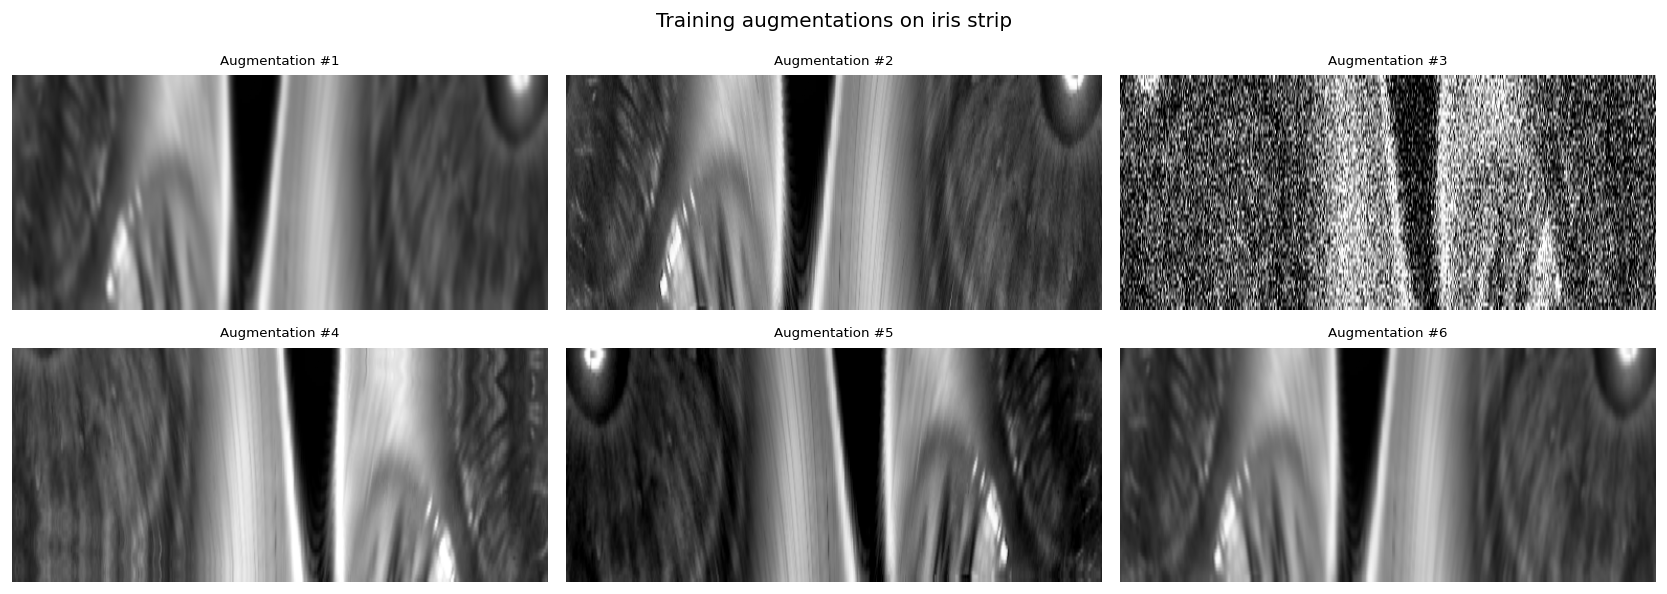

In [9]:
# ── Augmentation preview ─────────────────────
from augmentation import get_train_transform, augment_strip

transform = get_train_transform()
aug_strips = [augment_strip(strip_clahe, transform) for _ in range(6)]

fig, axes = plt.subplots(2, 3, figsize=(14, 5))
for i, (ax, s) in enumerate(zip(axes.flatten(), aug_strips)):
    ax.imshow(s, cmap='gray', aspect='auto')
    ax.set_title(f'Augmentation #{i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('Training augmentations on iris strip')
plt.tight_layout(); plt.show()